# Example: Paper Trading with the Cobb-Douglas Engine

In this example, we connect to the Alpaca paper trading API, replay the Session 2 Cobb-Douglas rebalancing engine on real historical market data with online SIM parameter updates, and execute a live paper trade with full execution cost decomposition.

> __Learning Objectives:__
>
> * __Connect to a brokerage API and fetch real market data:__ Set up an Alpaca paper trading client, select a ticker universe from the 424 pre-calibrated S&P 500 stocks, and fetch one year of daily OHLCV bars. Convert the raw bar data into the price matrix format consumed by the rebalancing engine.
> * __Replay the engine with online parameter updates:__ Run the Cobb-Douglas rebalancing engine day-by-day over real historical data, updating SIM parameters via exponentially weighted least squares. Compare the engine's performance to a buy-and-hold benchmark on the same real data.
> * __Execute and analyze a live paper trade:__ Submit market orders via Alpaca during market hours, verify fills, and decompose execution costs into spread, slippage, and regulatory fee components. Understand the gap between a backtest signal and a real-world fill.

Let's dive in!
___

## Setup, Data and Prerequisites
We begin by loading the `eCornellAIFinance` package and session dependencies via `Include.jl`. This also loads the `Alpaca` package for brokerage connectivity.

In [1]:
# Load the eCornellAIFinance package and session-3 dependencies (includes Alpaca)
include("Include.jl");


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


### Implementations
Notebook-local helper used by the performance scorecard.

`compute_scorecard_metrics(w)` takes a single-path wealth series and returns a `(W_multiple, max_drawdown, sharpe)` tuple. The scorecard calls it once per strategy (engine, buy-and-hold, market, risk-free) so every row is computed identically.

In [2]:
"""
    compute_scorecard_metrics(w::AbstractVector) -> (W_multiple, max_drawdown, sharpe)

Three summary numbers for a single wealth trajectory: terminal wealth as a
multiple of initial, max drawdown from running peak, and a simple Sharpe
ratio (total return / annualized daily-return vol). Returns `sharpe = 0`
when realized vol is zero (e.g. the risk-free path).
"""
function compute_scorecard_metrics(w::AbstractVector)
    returns  = diff(w) ./ w[1:end-1];
    peak     = accumulate(max, w);
    max_dd   = maximum((peak .- w) ./ peak);
    vol      = std(returns) * sqrt(252);
    mean_ret = w[end] / w[1] - 1.0;
    sharpe   = vol > 0 ? mean_ret / vol : 0.0;
    return (w[end] / w[1], max_dd, sharpe);
end;

### Constants


In [3]:
# Brokerage and replay configuration
CREDENTIALS_PATH = joinpath(_ROOT, "config", "credentials.toml")
ALPACA_SECTION   = "Credentials"  # named section in credentials.toml; change to route to a different paper account
my_tickers = ["AAPL", "MSFT", "GOOG", "AMZN", "NVDA"]
Δt = 1.0 / 252.0
rf = 0.05
B₀ = 10_000.0
N_short = 21
N_long = 63
offset = 63
N_growth = 10
GAIN = 10.0
default_half_life = 63.0
TRIGGER_MAX_DRAWDOWN = 0.15
TRIGGER_MAX_TURNOVER = 0.50
REALIZED_COST_BPS = 5.0
ALLOCATION_EPSILON = 0.1
ORDER_POLL_ATTEMPTS = 30
ORDER_POLL_INTERVAL_SECONDS = 1.0
EXECUTION_DATA_PATH = joinpath(_PATH_TO_DATA, "paper-trading-execution.jld2")

"/Users/jdv27/Desktop/julia_work/eCornell-AI-finance-lectures/lectures/session-4/data/paper-trading-execution.jld2"

In [4]:
client = let
    # --- Step 1: Load Alpaca credentials and connect ---
    # The credentials file is not checked into git. See config/credentials.toml.example
    # for the expected format, then create your own config/credentials.toml.
    creds_path = CREDENTIALS_PATH;
    if !isfile(creds_path)
        error("Credentials file not found at $(creds_path).\n" *
              "Copy config/credentials.toml.example to config/credentials.toml " *
              "and fill in your Alpaca paper trading API keys.")
    end
    client = Alpaca.load_client(creds_path; section = ALPACA_SECTION);

    # --- Verify which Alpaca account we are actually connected to ---
    acct = Alpaca.get_account(client);
    println("Connected account: $(acct.account_number)  status=$(acct.status)  ($(ALPACA_SECTION))");

    # --- Step 2: Check market clock ---
    clock = Alpaca.get_clock(client);
    println("Market status: $(clock.is_open ? "OPEN" : "CLOSED")")
    println("  Server time : $(clock.timestamp)")
    println("  Next open   : $(clock.next_open)")
    println("  Next close  : $(clock.next_close)")

    client
end


Connected account: PA3LQY85RCV6  status=ACTIVE  (Credentials)
Market status: CLOSED
  Server time : 2026-04-20T20:23:47
  Next open   : 2026-04-21T09:30:00
  Next close  : 2026-04-21T16:00:00


AlpacaClient("https://paper-api.alpaca.markets/v2", "https://data.alpaca.markets/v2", "https://data.alpaca.markets/v1beta1", "PKK5J4YX7KKAI57G4A2HN7WUZC", "7KE1GeEcS4v1E3CpXoCGDBUGYj3T7rDJJGkGMGnZuSYC")

___
## Task 1: Connect to the Brokerage API and Fetch Real Market Data
We select a ticker universe, load the pre-calibrated SIM parameters from Session 1, and fetch one year of daily bars from Alpaca.

> __From calibration to live data:__ The SIM parameters ($\alpha$, $\beta$, $\sigma_{\epsilon}$) were calibrated in Session 1 on 10 years of real VWAP data (2014-2024) for 424 S&P 500 stocks. We load these as starting points for each student-chosen ticker. In Task 2, we update them online as new data arrives via exponentially weighted least squares.

In the next cell, specify our ticker universe. Any subset of the 424 calibrated S&P 500 stocks is valid.

In [5]:
K, sim_params = let
    # --- Step 1: Student specifies their ticker universe ---
    # Change these to any subset of the 424 calibrated S&P 500 tickers.
    # Note: use calibration-era tickers (e.g., GOOG not GOOGL, NVDA not META).
    K = length(my_tickers);

    # --- Step 2: Load pre-calibrated SIM parameters ---
    calibration = load(joinpath(eCornellAIFinance._PATH_TO_DATA, "sim-calibration.jld2"));
    all_tickers = calibration["tickers"];
    all_alpha = calibration["alpha"];
    all_beta = calibration["beta"];
    all_sigma = calibration["sigma_eps"];

    # build a lookup and validate -
    ticker_idx = Dict(all_tickers[i] => i for i in eachindex(all_tickers));
    for t in my_tickers
        haskey(ticker_idx, t) || error("Ticker $(t) not found in calibration set.");
    end

    sim_params = Dict{String,Tuple{Float64,Float64,Float64}}(
        t => (all_alpha[ticker_idx[t]], all_beta[ticker_idx[t]], all_sigma[ticker_idx[t]])
        for t in my_tickers
    );

    # --- Step 3: Display SIM parameters ---
    df = DataFrame(
        "Ticker" => my_tickers,
        "α (1/yr)" => [round(sim_params[t][1], digits=6) for t in my_tickers],
        "β" => [round(sim_params[t][2], digits=4) for t in my_tickers],
        "σ_ε (1/yr)" => [round(sim_params[t][3], digits=6) for t in my_tickers]
    );
    println("Pre-calibrated SIM parameters for $(K) tickers:");
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
    K, sim_params
end


Pre-calibrated SIM parameters for 5 tickers:
 -------- ---------- --------- ------------
  Ticker   α (1/yr)         β   σ_ε (1/yr) 
  String    Float64   Float64      Float64 
 -------- ---------- --------- ------------
    AAPL   0.106055    1.1946      2.70119
    MSFT   0.099926     1.152      2.36556
    GOOG   -0.01382    1.1927      4.27518
    AMZN   0.086309    1.2496      3.53334
    NVDA    0.34678    1.7493      4.89788
 -------- ---------- --------- ------------


(5, Dict("MSFT" => (0.09992562742912167, 1.1520141674858755, 2.365559321564307), "AMZN" => (0.08630850659055037, 1.2495730224705, 3.533339005947076), "GOOG" => (-0.013820122831404326, 1.1927044218299412, 4.275177607224215), "NVDA" => (0.3467801969777642, 1.7492585467618145, 4.897882624770674), "AAPL" => (0.10605520914187132, 1.194586402866034, 2.7011910056020154)))

We fetch one year of daily bars from Alpaca for the selected tickers plus SPY as the market proxy.

In [6]:
market_prices, price_matrix = let
    # --- Step 1: Define date range (1 year of history) ---
    finish_date = Dates.format(today(), "yyyy-mm-dd");
    start_date = Dates.format(today() - Year(1), "yyyy-mm-dd");

    # --- Step 2: Fetch daily bars for tickers + SPY ---
    symbols = vcat(my_tickers, ["SPY"]);
    println("Fetching daily bars for $(length(symbols)) symbols: $(start_date) to $(finish_date)...");
    bars_dict = Alpaca.get_bars(client, symbols, "1Day";
        start = start_date, finish = finish_date);

    # --- Step 3: Extract close prices and align dates ---
    # Use SPY dates as the reference calendar (most liquid, no gaps)
    spy_bars = bars_dict["SPY"];
    n_days = length(spy_bars);
    market_prices = [b.c for b in spy_bars];

    # build price matrix: col 1 = day index, cols 2:K+1 = ticker close prices
    price_matrix = zeros(n_days, K + 1);
    price_matrix[:, 1] = 1:n_days;
    for (k, ticker) in enumerate(my_tickers)
        ticker_bars = bars_dict[ticker];
        n_ticker = min(length(ticker_bars), n_days);
        for i in 1:n_ticker
            price_matrix[i, k + 1] = ticker_bars[i].c;
        end
    end

    println("Fetched $(n_days) trading days for $(length(symbols)) symbols.")
    market_prices, price_matrix
end


Fetching daily bars for 6 symbols: 2025-04-20 to 2026-04-20...
Fetched 251 trading days for 6 symbols.


([513.96, 526.95, 535.29, 546.44, 550.55, 551.07, 554.09, 554.02, 558.4, 566.56  …  659.23, 676.0, 679.87, 679.35, 686.0, 694.36, 699.75, 701.53, 710.06, 708.79], [1.0 193.25 … 167.35 96.77; 2.0 199.56 … 173.13 98.865; … ; 250.0 270.205 … 250.49 201.67; 251.0 273.06 … 248.34 202.12])

We display the tail of the price matrix and plot the normalized price paths.

In [7]:
let
    # --- Display tail of price matrix ---
    n_show = min(10, size(price_matrix, 1));
    tail_start = size(price_matrix, 1) - n_show + 1;
    df = DataFrame(
        "Day" => Int.(price_matrix[tail_start:end, 1]),
        [t => round.(price_matrix[tail_start:end, k + 1], digits=2) for (k, t) in enumerate(my_tickers)]...
    );
    println("Price matrix (last $(n_show) days):");
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

Price matrix (last 10 days):
 ------- --------- --------- --------- --------- ---------
    Day      AAPL      MSFT      GOOG      AMZN      NVDA 
  Int64   Float64   Float64   Float64   Float64   Float64 
 ------- --------- --------- --------- --------- ---------
    242    253.59     372.4    304.05    213.81    178.11
    243    258.97    374.26     314.8    221.33    182.12
    244    260.44    372.99    316.34    233.53    183.88
    245    260.43    370.89    315.73    238.42    188.61
    246    259.13    384.33    319.19    239.95    189.24
    247    258.77    393.02    330.54    249.07     196.5
    248    266.31     411.3    334.44    248.46    198.85
    249    263.32    420.12     332.8     249.7    198.26
    250     270.2    422.75    339.34    250.49    201.67
    251    273.06    418.11    335.44    248.34    202.12
 ------- --------- --------- --------- --------- ---------


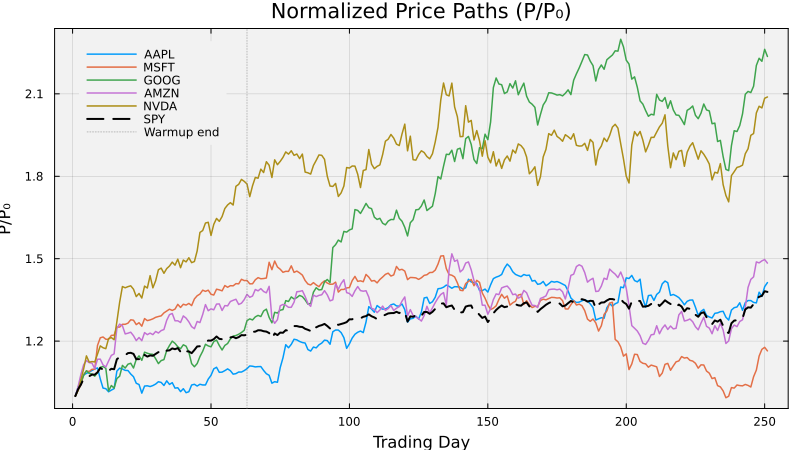

In [8]:
let
    # --- Plot normalized price paths P/P₀ ---
    n_days = size(price_matrix, 1);
    p = plot(size=(800, 450), title="Normalized Price Paths (P/P₀)",
        xlabel="Trading Day", ylabel="P/P₀", legend=:topleft,
        bg="gray95", background_color_outside="white", framestyle=:box, fg_legend=:transparent);

    for (k, ticker) in enumerate(my_tickers)
        prices_k = price_matrix[:, k + 1];
        plot!(p, 1:n_days, prices_k ./ prices_k[1], label=ticker, linewidth=1.5);
    end

    # add SPY
    plot!(p, 1:n_days, market_prices ./ market_prices[1],
        label="SPY", linewidth=2, color=:black, linestyle=:dash);

    # mark warmup boundary
    vline!(p, [offset], label="Warmup end", linestyle=:dot, color=:gray, alpha=0.5);
    p
end

___
## Task 2: Replay the Engine with Online Parameter Updates
We run the Cobb-Douglas engine day-by-day over the real historical data, updating SIM parameters via exponentially weighted least squares (EWLS) at each time step. The first 63 days serve as a warm-up period for the EWLS estimator.

> __EWLS extends the OLS from Session 1:__ The SIM regression $g_{i,t} = \alpha_i + \beta_i \cdot g_{m,t} + \epsilon_{i,t}$ is the same as Session 1, but now each observation is weighted by $\eta^{T-t}$ where $\eta = 2^{-1/h}$ and $h$ is the half-life in days. An observation from $h$ days ago receives half the weight of today's observation. This lets the model adapt to regime changes while retaining memory of stable periods.

In the next cell, we initialize the EWLS states from the pre-calibrated parameters and run the replay.

In [9]:
rules_params, replay, bh_wealth, mkt_wealth, rf_wealth = let
    # --- Step 1: Define trigger rules (same as Session 2) ---
    rules_params = (max_drawdown = TRIGGER_MAX_DRAWDOWN, max_turnover = TRIGGER_MAX_TURNOVER);

    # --- Step 2: Run the EWLS engine replay ---
    println("Running EWLS engine replay (half-life = $(default_half_life) days)...");
    replay = replay_engine_ewls(price_matrix, market_prices, my_tickers, sim_params, rules_params;
        B₀ = B₀, offset = offset, half_life = default_half_life,
        N_short = N_short, N_long = N_long, GAIN = GAIN, N_growth = N_growth,
        cost_bps = REALIZED_COST_BPS, epsilon = ALLOCATION_EPSILON);

    # --- Step 3: Run buy-and-hold benchmark on same real data ---
    n_days = size(price_matrix, 1);
    n_trading = n_days - offset;
    bh_shares = [B₀ / K / price_matrix[offset, k + 1] for k in 1:K];
    bh_wealth = zeros(n_trading + 1);
    for d in 0:n_trading
        day = offset + d;
        bh_wealth[d + 1] = sum(bh_shares[k] * price_matrix[day, k + 1] for k in 1:K);
    end

    # market buy-and-hold (SPY only)
    mkt_shares_count = B₀ / market_prices[offset];
    mkt_wealth = [mkt_shares_count * market_prices[offset + d] for d in 0:n_trading];

    # risk-free
    rf_wealth = [B₀ * exp(rf * d * Δt) for d in 0:n_trading];

    println("Replay complete: $(n_trading) trading days after $(offset)-day warmup.");
    rules_params, replay, bh_wealth, mkt_wealth, rf_wealth
end


Running EWLS engine replay (half-life = 63.0 days)...
Replay complete: 188 trading days after 63-day warmup.


((max_drawdown = 0.15, max_turnover = 0.5), (results = Dict{Int64, MyRebalancingResult}(56 => MyRebalancingResult([8.453418065922433, 3.1504882004808668, 12.941628526560251, 2.4530060984419717, 19.08221003719729], -1.074770287067482, [0.40787999001015685, 0.30912604893846113, 0.5940408914025282, 0.10329859397825494, 0.6747515876441758], 0.0), 35 => MyRebalancingResult([6.936521061407585, 2.9696702501069527, 11.310794464696308, 9.348303731455154, 16.058875960381016], -0.2060409596912796, [0.4746336190281899, 0.432179568998601, 0.792306631559701, 0.6502510988064464, 0.8006223056473213], 0.0), 60 => MyRebalancingResult([3.3678799681498415, 1.7075784168318981, 28.3205493024457, 0.1463171102854053, 12.686696763247735], 218.17811553027002, [0.11949252377092225, 0.12581420511623603, 0.4655917060688586, -0.28741796679375015, 0.29962369495909824], 0.0), 67 => MyRebalancingResult([9.086075225210157, 3.388942949499364, 10.183021487383487, 9.627949879985994, 15.188101826296846], -1.025942454416547

We display the performance scorecard comparing the engine, buy-and-hold, market, and risk-free strategies on real data.

In [10]:
let
    # --- Compute metrics for each strategy via the Setup helper ---
    eng = compute_scorecard_metrics(replay.wealth);
    bh = compute_scorecard_metrics(bh_wealth);
    mkt = compute_scorecard_metrics(mkt_wealth);
    rfm = compute_scorecard_metrics(rf_wealth);

    df = DataFrame(
        "Strategy" => ["CD Engine (EWLS)", "Buy-and-Hold (EW)", "Market (SPY)", "Risk-Free"],
        "W/W₀" => [round(eng[1], digits=4), round(bh[1], digits=4), round(mkt[1], digits=4), round(rfm[1], digits=4)],
        "Max DD (%)" => [round(eng[2]*100, digits=1), round(bh[2]*100, digits=1), round(mkt[2]*100, digits=1), round(rfm[2]*100, digits=1)],
        "Sharpe" => [round(eng[3], digits=3), round(bh[3], digits=3), round(mkt[3], digits=3), round(rfm[3], digits=3)]
    );
    println("Performance Scorecard (real data, $(size(price_matrix,1) - offset) trading days):");
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

Performance Scorecard (real data, 188 trading days):
 ------------------- --------- ------------ ------------
           Strategy      W/W₀   Max DD (%)       Sharpe 
             String   Float64      Float64      Float64 
 ------------------- --------- ------------ ------------
   CD Engine (EWLS)    1.4854          9.3        2.844
  Buy-and-Hold (EW)    1.2241         15.7        1.187
       Market (SPY)    1.1273          9.1        1.017
          Risk-Free     1.038          0.0   1.76289e13
 ------------------- --------- ------------ ------------


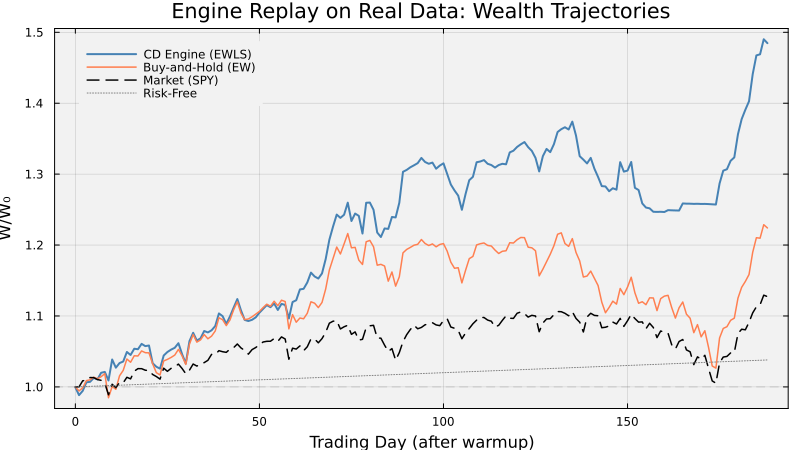

In [11]:
let
    # --- Plot wealth trajectories ---
    n_trading = length(replay.wealth);
    days = 0:(n_trading - 1);

    p = plot(size=(800, 450), title="Engine Replay on Real Data: Wealth Trajectories",
        xlabel="Trading Day (after warmup)", ylabel="W/W₀", legend=:topleft,
        bg="gray95", background_color_outside="white", framestyle=:box, fg_legend=:transparent);

    plot!(p, days, replay.wealth ./ B₀, label="CD Engine (EWLS)", linewidth=2, color=:steelblue);
    plot!(p, days, bh_wealth ./ B₀, label="Buy-and-Hold (EW)", linewidth=1.5, color=:coral);
    plot!(p, days, mkt_wealth ./ B₀, label="Market (SPY)", linewidth=1.5, color=:black, linestyle=:dash);
    plot!(p, days, rf_wealth ./ B₀, label="Risk-Free", linewidth=1, color=:gray, linestyle=:dot);
    hline!(p, [1.0], label="", linestyle=:dash, color=:gray, alpha=0.3);
    p
end

We visualize how the SIM parameters drift over time as the EWLS estimator adapts to new data.

Parameter drift (calibrated → EWLS final):
 -------- ---------------- ---------------- ---------
  Ticker   β (calibrated)   β (final EWLS)        Δβ 
  String          Float64          Float64   Float64 
 -------- ---------------- ---------------- ---------
    AAPL           1.1946            0.919   -0.2756
    MSFT            1.152           0.9933   -0.1588
    GOOG           1.1927           1.2793    0.0866
    AMZN           1.2496           1.4559    0.2063
    NVDA           1.7493           1.7437   -0.0056
 -------- ---------------- ---------------- ---------


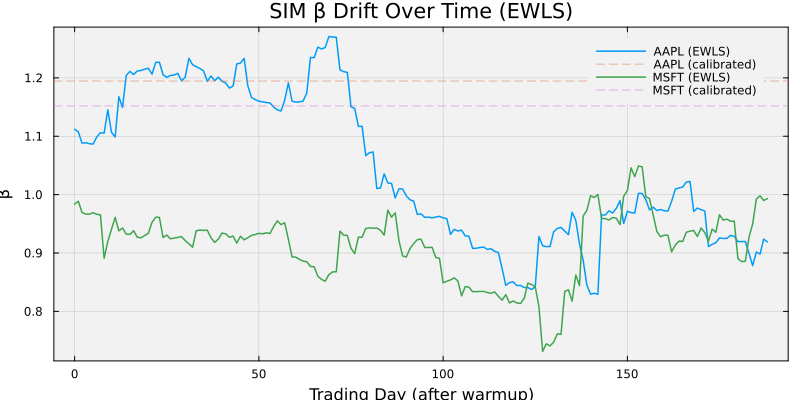

In [12]:
let
    # --- Plot β drift for first 2 tickers ---
    p = plot(size=(800, 400), title="SIM β Drift Over Time (EWLS)",
        xlabel="Trading Day (after warmup)", ylabel="β", legend=:topright,
        bg="gray95", background_color_outside="white", framestyle=:box, fg_legend=:transparent);

    n_show = min(2, K);
    for k in 1:n_show
        ticker = my_tickers[k];
        β_hist = [p[2] for p in replay.param_history[ticker]];
        β_init = sim_params[ticker][2];
        plot!(p, 0:(length(β_hist)-1), β_hist, label="$(ticker) (EWLS)", linewidth=1.5);
        hline!(p, [β_init], label="$(ticker) (calibrated)", linestyle=:dash, alpha=0.5);
    end

    # show parameter drift table -
    df = DataFrame(
        "Ticker" => my_tickers,
        "β (calibrated)" => [round(sim_params[t][2], digits=4) for t in my_tickers],
        "β (final EWLS)" => [round(replay.param_history[t][end][2], digits=4) for t in my_tickers],
        "Δβ" => [round(replay.param_history[t][end][2] - sim_params[t][2], digits=4) for t in my_tickers]
    );
    println("Parameter drift (calibrated → EWLS final):");
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    p
end

We sweep the EWLS half-life to explore the bias-variance tradeoff.

EWLS Sensitivity Sweep:
 ------------------ --------- ---------
  Half-Life (days)      W/W₀    Sharpe 
             Int64   Float64   Float64 
 ------------------ --------- ---------
                21    1.4411     2.366
                42    1.4808     2.792
                63    1.4854     2.844
                84     1.476     2.759
               126    1.4533     2.659
 ------------------ --------- ---------


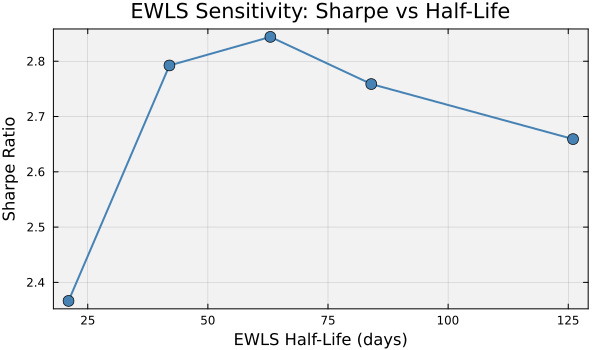

In [13]:
let
    # --- EWLS Sensitivity Sweep ---
    half_lives = [21.0, 42.0, 63.0, 84.0, 126.0];
    results_sweep = [];

    for hl in half_lives
        r = replay_engine_ewls(price_matrix, market_prices, my_tickers, sim_params, rules_params;
            B₀ = B₀, offset = offset, half_life = hl,
            N_short = N_short, N_long = N_long, GAIN = GAIN, N_growth = N_growth,
            cost_bps = 5.0, epsilon = 0.1);

        w = r.wealth;
        returns = diff(w) ./ w[1:end-1];
        vol = std(returns) * sqrt(252);
        mean_ret = w[end] / w[1] - 1.0;
        sharpe = vol > 0 ? mean_ret / vol : 0.0;
        push!(results_sweep, (hl, w[end]/w[1], sharpe));
    end

    # display table -
    df = DataFrame(
        "Half-Life (days)" => [Int(r[1]) for r in results_sweep],
        "W/W₀" => [round(r[2], digits=4) for r in results_sweep],
        "Sharpe" => [round(r[3], digits=3) for r in results_sweep]
    );
    println("EWLS Sensitivity Sweep:");
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    # plot Sharpe vs half-life -
    p = plot([r[1] for r in results_sweep], [r[3] for r in results_sweep],
        xlabel="EWLS Half-Life (days)", ylabel="Sharpe Ratio",
        title="EWLS Sensitivity: Sharpe vs Half-Life",
        marker=:circle, markersize=6, linewidth=2, color=:steelblue, label="",
        size=(600, 350),
        bg="gray95", background_color_outside="white", framestyle=:box);
    p
end

The engine's historical performance on real data supports deployment. Let's execute today's allocation live.

___
## Task 3: Execute and Analyze a Live Paper Trade
We take the engine's target allocation and execute it as a real paper trade via Alpaca. The notebook detects whether the market is open and operates in one of two modes.

> __Signal price vs fill price:__ The signal price is the bid-ask midpoint at the moment the engine computes its target allocation. The fill price is what the market gives us when the order executes. The difference is the implementation cost, which decomposes into three components: spread cost (crossing the bid-ask), slippage (market moved between signal and fill), and regulatory fees (SEC and FINRA charges on sells).

In the next cell, we check the market clock and either execute live or load recorded results.

In [14]:
is_live, execution_data_path = let
    # --- Determine execution mode ---
    clock = Alpaca.get_clock(client);
    is_live = clock.is_open;
    execution_data_path = EXECUTION_DATA_PATH;

    if is_live
        println("LIVE MODE: Market is OPEN. Will execute real paper trades.")
    else
        if isfile(execution_data_path)
            println("REVIEW MODE: Market is CLOSED. Loading recorded execution results.")
        else
            println("REVIEW MODE: Market is CLOSED and no recorded results found.")
            println("Run this notebook during market hours (9:30am-4pm ET) to execute live trades.")
        end
    end
    is_live, execution_data_path
end


REVIEW MODE: Market is CLOSED. Loading recorded execution results.


(false, "/Users/jdv27/Desktop/julia_work/eCornell-AI-finance-lectures/lectures/session-4/data/paper-trading-execution.jld2")

In [15]:
signal_data, target_shares_dict, current_shares_dict = let
    if is_live
        # === LIVE MODE: Signal Generation ===

        # --- Step 1: Fetch latest quotes (one per ticker) ---
        println("Fetching latest quotes...");
        signal_data = Dict{String,NamedTuple}();
        for ticker in my_tickers
            q = Alpaca.get_latest_quote(client, ticker);
            mid = (q.ask_price + q.bid_price) / 2.0;
            signal_data[ticker] = (bid = q.bid_price, ask = q.ask_price, mid = mid, spread = q.ask_price - q.bid_price);
        end

        # --- Step 2: Compute target allocation ---
        # Use final EWLS params from Task 2
        ewls_params = Dict{String,Tuple{Float64,Float64,Float64}}(
            t => replay.param_history[t][end] for t in my_tickers
        );

        # compute current lambda from latest EMAs
        ema_s = compute_ema(market_prices; window = N_short);
        ema_l = compute_ema(market_prices; window = N_long);
        λ_series = compute_lambda(ema_s, ema_l; G = GAIN);
        λ_current = λ_series[end];

        # compute market growth EMA
        gm_raw = compute_market_growth(market_prices; Δt = Δt);
        gm_ema = compute_ema(gm_raw; window = N_growth);
        gm_current = gm_ema[end];

        # compute preference weights and target shares
        gamma = compute_preference_weights(ewls_params, my_tickers, gm_current, λ_current);
        signal_prices = [signal_data[t].mid for t in my_tickers];

        problem = MyCobbDouglasChoiceProblem();
        problem.gamma = gamma;
        problem.prices = signal_prices;
        problem.B = B₀;
        problem.epsilon = ALLOCATION_EPSILON;
        (target_shares, target_cash) = allocate_cobb_douglas(problem);
        target_shares_dict = Dict(my_tickers[k] => target_shares[k] for k in 1:K);

        # --- Step 3: Get current positions ---
        positions = Alpaca.list_positions(client);
        current_shares_dict = Dict{String,Float64}();
        for ticker in my_tickers
            found = false;
            for pos in positions
                if pos.symbol == ticker
                    current_shares_dict[ticker] = pos.qty;
                    found = true;
                    break;
                end
            end
            if !found
                current_shares_dict[ticker] = 0.0;
            end
        end

        println("Signal generated: λ = $(round(λ_current, digits=3)), gm_ema = $(round(gm_current, digits=4))");
        println("Target allocation computed for $(K) tickers.")

    elseif isfile(execution_data_path)
        # === REVIEW MODE: Load recorded results ===
        saved = load(execution_data_path);
        signal_data = saved["signal_data"];
        target_shares_dict = saved["target_shares"];
        current_shares_dict = saved["current_shares_before"];
        println("Loaded recorded execution from $(saved["timestamp"]).");
        println("To run live, execute during market hours (9:30am-4pm ET).")
    end
    signal_data, target_shares_dict, current_shares_dict
end


Loaded recorded execution from 2026-04-15T12:36:19.524.
To run live, execute during market hours (9:30am-4pm ET).


(Dict{String, NamedTuple}("MSFT" => (bid = 408.45, ask = 409.77, mid = 409.11, spread = 1.3199999999999932), "AMZN" => (bid = 248.37, ask = 248.4, mid = 248.385, spread = 0.030000000000001137), "GOOG" => (bid = 329.0, ask = 332.17, mid = 330.58500000000004, spread = 3.170000000000016), "NVDA" => (bid = 198.62, ask = 198.64, mid = 198.63, spread = 0.01999999999998181), "AAPL" => (bid = 265.13, ask = 265.16, mid = 265.145, spread = 0.03000000000002956)), Dict("MSFT" => 4.364095932440684, "AMZN" => 8.449818978915424, "GOOG" => 6.3270728006481, "NVDA" => 10.64953900672307, "AAPL" => 7.199242419406847), Dict("MSFT" => 4.4, "AMZN" => 8.41, "GOOG" => 6.31, "NVDA" => 10.57, "AAPL" => 7.21))

In [16]:
order_results = let
    if is_live
        # === LIVE MODE: Submit Orders ===

        # --- Step 1: Compute order deltas ---
        order_results = Dict{String,NamedTuple}();
        for ticker in my_tickers
            delta = target_shares_dict[ticker] - current_shares_dict[ticker];
            if abs(delta) < 0.01
                order_results[ticker] = (side = "none", qty = 0.0, fill_price = signal_data[ticker].mid,
                    status = "no_trade", order_id = "");
                continue;
            end

            side = delta > 0 ? "buy" : "sell";
            qty = round(abs(delta), digits=2);

            # --- Step 2: Submit market order ---
            println("Submitting $(uppercase(side)) $(qty) $(ticker)...");
            order = Alpaca.submit_order(client, ticker, qty, side;
                type = "market", time_in_force = "day");

            # --- Step 3: Poll for fill ---
            fill_price = 0.0;
            status = "pending";
            for attempt in 1:ORDER_POLL_ATTEMPTS  # poll up to 30 seconds
                sleep(ORDER_POLL_INTERVAL_SECONDS);
                updated = Alpaca.get_order(client, order.id);
                if updated.status == "filled"
                    fill_price = updated.filled_avg_price;
                    status = "filled";
                    println("  $(ticker): FILLED at \$$(round(fill_price, digits=2))");
                    break;
                end
                status = updated.status;
            end

            order_results[ticker] = (side = side, qty = qty, fill_price = fill_price,
                status = status, order_id = order.id);
        end

    elseif isfile(execution_data_path)
        # === REVIEW MODE ===
        saved = load(execution_data_path);
        order_results = saved["order_results"];
        println("Order results loaded from recorded execution.")
    end
    order_results
end


Order results loaded from recorded execution.


Dict{String, NamedTuple} with 5 entries:
  "MSFT" => (side = "sell", qty = 0.04, fill_price = 408.53, status = "filled",…
  "AMZN" => (side = "buy", qty = 0.04, fill_price = 248.374, status = "filled",…
  "GOOG" => (side = "buy", qty = 0.02, fill_price = 332.154, status = "filled",…
  "NVDA" => (side = "buy", qty = 0.08, fill_price = 198.638, status = "filled",…
  "AAPL" => (side = "sell", qty = 0.01, fill_price = 265.134, status = "filled"…

In [17]:
let
    if !@isdefined(order_results) || isempty(order_results)
        println("No execution data available. Run during market hours or ensure recorded results exist.")
    else
        # === Cost Decomposition ===

        tickers_list = String[];
        sides = String[];
        qtys = Float64[];
        signal_mids = Float64[];
        fill_prices = Float64[];
        spread_costs = Float64[];
        slippages = Float64[];
        reg_fees = Float64[];
        total_costs = Float64[];

        for ticker in my_tickers
            or = order_results[ticker];
            sd = signal_data[ticker];

            if or.status == "no_trade"
                continue;
            end

            push!(tickers_list, ticker);
            push!(sides, or.side);
            push!(qtys, or.qty);
            push!(signal_mids, sd.mid);
            push!(fill_prices, or.fill_price);

            # spread cost: half the bid-ask spread per share
            half_spread = sd.spread / 2.0;
            spread_cost = half_spread * or.qty;
            push!(spread_costs, spread_cost);

            # slippage: residual after spread
            raw_slip = abs(or.fill_price - sd.mid) - half_spread;
            slippage = max(raw_slip, 0.0) * or.qty;
            push!(slippages, slippage);

            # regulatory fees (sells only)
            reg = 0.0;
            if or.side == "sell"
                notional = or.fill_price * or.qty;
                sec_fee = notional * 8.0 / 1_000_000.0;      # SEC: $8 per $1M
                finra_taf = or.qty * 0.000119;                 # FINRA TAF: $0.000119/share
                reg = sec_fee + finra_taf;
            end
            push!(reg_fees, reg);
            push!(total_costs, spread_cost + slippage + reg);
        end

        if length(tickers_list) > 0
            # --- Execution Report ---
            df_exec = DataFrame(
                "Ticker" => tickers_list,
                "Side" => sides,
                "Qty" => round.(qtys, digits=2),
                "Signal Mid" => round.(signal_mids, digits=2),
                "Fill Price" => round.(fill_prices, digits=2),
                "Spread (\$)" => round.(spread_costs, digits=4),
                "Slippage (\$)" => round.(slippages, digits=4),
                "Reg Fees (\$)" => round.(reg_fees, digits=4),
                "Total Cost (\$)" => round.(total_costs, digits=4)
            );
            println("Execution Cost Decomposition:");
            pretty_table(df_exec; backend = :text,
                fit_table_in_display_horizontally = false,
                fit_table_in_display_vertically = false,
                table_format = TextTableFormat(borders = text_table_borders__compact))

            # --- Portfolio-level totals ---
            total = sum(total_costs);
            total_notional = sum(fill_prices .* qtys);
            bps = total_notional > 0 ? total / total_notional * 10_000.0 : 0.0;
            println("Total execution cost: \$$(round(total, digits=4)) ($(round(bps, digits=1)) bps of traded value)");
        end

        # --- Position Verification ---
        df_pos = DataFrame(
            "Ticker" => my_tickers,
            "Target Shares" => [round(target_shares_dict[t], digits=2) for t in my_tickers],
            "Before" => [round(current_shares_dict[t], digits=2) for t in my_tickers],
            "Delta" => [round(target_shares_dict[t] - current_shares_dict[t], digits=2) for t in my_tickers]
        );
        println("\nPosition Verification:");
        pretty_table(df_pos; backend = :text,
            fit_table_in_display_horizontally = false,
            fit_table_in_display_vertically = false,
            table_format = TextTableFormat(borders = text_table_borders__compact))
    end
end

Execution Cost Decomposition:
 -------- -------- --------- ------------ ------------ ------------ -------------- -------------- ----------------
  Ticker     Side       Qty   Signal Mid   Fill Price   Spread ($)   Slippage ($)   Reg Fees ($)   Total Cost ($) 
  String   String   Float64      Float64      Float64      Float64        Float64        Float64          Float64 
 -------- -------- --------- ------------ ------------ ------------ -------------- -------------- ----------------
    AAPL     sell      0.01       265.14       265.13       0.0002            0.0            0.0           0.0002
    MSFT     sell      0.04       409.11       408.53       0.0264            0.0         0.0001           0.0265
    GOOG      buy      0.02       330.58       332.15       0.0317            0.0            0.0           0.0317
    AMZN      buy      0.04       248.38       248.37       0.0006            0.0            0.0           0.0006
    NVDA      buy      0.08       198.63       198.64 

In [18]:
let
    if is_live
        # === LIVE MODE: Fetch account summary and save results ===

        # --- Account Summary ---
        acct = Alpaca.get_account(client);
        df_acct = DataFrame(
            "Metric" => ["Equity", "Cash", "Buying Power", "Portfolio Value"],
            "Value (\$)" => [
                round(acct.equity, digits=2),
                round(acct.cash, digits=2),
                round(acct.buying_power, digits=2),
                round(acct.portfolio_value, digits=2)
            ]
        );
        println("Account Summary:");
        pretty_table(df_acct; backend = :text,
            fit_table_in_display_horizontally = false,
            fit_table_in_display_vertically = false,
            table_format = TextTableFormat(borders = text_table_borders__compact))

        # --- Save execution results for Review Mode ---
        save(execution_data_path, Dict(
            "timestamp" => string(now()),
            "tickers" => my_tickers,
            "signal_data" => signal_data,
            "target_shares" => target_shares_dict,
            "current_shares_before" => current_shares_dict,
            "order_results" => order_results,
            "account_equity" => acct.equity,
            "account_cash" => acct.cash,
            "account_buying_power" => acct.buying_power,
            "account_portfolio_value" => acct.portfolio_value
        ));
        println("\nExecution results saved to $(execution_data_path)");
        println("Students running this notebook after hours will see these results in Review Mode.");

    elseif isfile(execution_data_path)
        # === REVIEW MODE: Display saved account snapshot ===
        saved = load(execution_data_path);
        df_acct = DataFrame(
            "Metric" => ["Equity", "Cash", "Buying Power", "Portfolio Value"],
            "Value (\$)" => [
                round(saved["account_equity"], digits=2),
                round(saved["account_cash"], digits=2),
                round(saved["account_buying_power"], digits=2),
                round(saved["account_portfolio_value"], digits=2)
            ]
        );
        println("Account Summary (recorded at $(saved["timestamp"])):");
        pretty_table(df_acct; backend = :text,
            fit_table_in_display_horizontally = false,
            fit_table_in_display_vertically = false,
            table_format = TextTableFormat(borders = text_table_borders__compact))
    end
end

Account Summary (recorded at 2026-04-15T12:36:19.524):
 ----------------- -----------
           Metric   Value ($) 
           String     Float64 
 ----------------- -----------
           Equity     10521.1
             Cash      513.78
     Buying Power     11034.9
  Portfolio Value     10521.1
 ----------------- -----------


___
## Summary
We connected to a real brokerage API, replayed the Cobb-Douglas engine on real historical data with online parameter updates, and executed a live paper trade with full cost analysis.

> __Key Takeaways:__
>
> * __EWLS adapts SIM parameters to current market conditions:__ By exponentially down-weighting old observations, the estimator lets $\alpha$ and $\beta$ drift as regimes change. The half-life controls the speed of adaptation, with shorter half-lives reacting faster but introducing more estimation noise.
> * __Real data performance validates the backtest:__ Running the engine on actual market data bridges the gap between synthetic Monte Carlo scenarios and production deployment. The scorecard on real data gives a concrete check against the distributional results from the HMM backtest.
> * __Execution costs are small but measurable:__ The spread, slippage, and regulatory fee decomposition shows where money is lost between signal and fill. For liquid large-cap equities with market orders, total costs are typically single-digit basis points per trade.

The engine is now deployed in a paper trading account. In Session 4, we build the production monitoring and escalation system around it.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice.

___